# Week 9 Challenge

# Task 5 - Strategy Backtesting

Author: Lalise Fufi

Date: July 2026

Objective:
Validate the Task 4 optimized portfolio by simulating its historical
performance over the last year of data (data NOT used for model training)
and comparing it against a simple passive 60% SPY / 40% BND benchmark.

**Recap:**
- Task 2 trained models on 2015-2024 and held out 2025-2026 as the test set.
- Task 3 forecasted TSLA 12 months forward using the winning LSTM model.
- Task 4 used that forecast to build an optimized portfolio (Max Sharpe /
  Tangency Portfolio) via PyPortfolioOpt, saved to
  `../data/processed/optimal_portfolio.csv`.
- This notebook backtests that same optimized portfolio over
  **2025-01-01 to the end of the dataset (2026-06-30)** — the identical
  window that was held out from model training, so no look-ahead bias is
  introduced here either.

1. Import Libraries

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Register pandas datetime converters with matplotlib up front — avoids the
# ConversionError encountered in Task 3 when plotting a DatetimeIndex.
pd.plotting.register_matplotlib_converters()

plt.style.use("ggplot")


2. Load Historical Price Data (TSLA, BND, SPY)

Same fixed loader used in Tasks 3 and 4: `skiprows=[1, 2]` skips both junk header rows (`Ticker` and `Date`) in the raw yfinance CSV export, so the index parses as a clean `DatetimeIndex`.

In [2]:
def load_close_prices(ticker):
    df = pd.read_csv(
        f"../data/raw/{ticker}.csv",
        skiprows=[1, 2],
        index_col=0,
        parse_dates=True
    )
    df.index.name = "Date"
    close = df["Close"].sort_index()
    close = pd.to_numeric(close, errors="coerce").dropna()
    return close

tsla_close = load_close_prices("TSLA")
bnd_close = load_close_prices("BND")
spy_close = load_close_prices("SPY")

prices = pd.DataFrame({
    "TSLA": tsla_close,
    "BND": bnd_close,
    "SPY": spy_close
}).dropna()

assert isinstance(prices.index, pd.DatetimeIndex), "prices index is not datetime!"

print(prices.shape)
prices.tail()


(2888, 3)


,TSLA,BND,SPY
Date,,,
2026-06-23,381.609985,72.976631,733.580017
2026-06-24,375.529999,73.305534,733.239990
2026-06-25,375.119995,73.355370,734.299988
2026-06-26,379.709991,73.425133,728.989990
2026-06-29,411.839996,73.465004,741.000000


3. Load the Optimized Portfolio Weights from Task 4

In [3]:
optimal_portfolio = pd.read_csv("../data/processed/optimal_portfolio.csv")
optimal_portfolio = optimal_portfolio.set_index("Asset")["Weight"]

# ensure consistent asset order everywhere: TSLA, BND, SPY
ASSET_ORDER = ["TSLA", "BND", "SPY"]
strategy_weights = optimal_portfolio.reindex(ASSET_ORDER).values

print("Strategy (Max Sharpe) weights:")
for asset, w in zip(ASSET_ORDER, strategy_weights):
    print(f"  {asset}: {w:.2%}")


Strategy (Max Sharpe) weights:
  TSLA: 0.00%
  BND: 0.00%
  SPY: 100.00%


4. Define the Backtesting Window and Benchmark

Backtest window: **2025-01-01 through the end of the dataset (2026-06-30)**. This is exactly the data withheld from model training in Task 2, so the backtest is a fair, unbiased test.

Benchmark: a static **60% SPY / 40% BND** balanced portfolio, as suggested in the challenge brief.

In [4]:
BACKTEST_START = "2025-01-01"
BACKTEST_END = prices.index.max()

backtest_prices = prices.loc[BACKTEST_START:BACKTEST_END]
backtest_returns = backtest_prices.pct_change().dropna()

print("Backtest window:", backtest_returns.index.min(), "to", backtest_returns.index.max())
print("Trading days in window:", len(backtest_returns))

benchmark_weights = np.array([0.0, 0.40, 0.60])  # [TSLA, BND, SPY] -> 0% TSLA, 40% BND, 60% SPY

print("\nBenchmark weights:")
for asset, w in zip(ASSET_ORDER, benchmark_weights):
    print(f"  {asset}: {w:.0%}")


Backtest window: 2025-01-03 00:00:00 to 2026-06-29 00:00:00
Trading days in window: 371

Benchmark weights:
  TSLA: 0%
  BND: 40%
  SPY: 60%


5. Portfolio Simulation Function (Monthly Rebalancing)

At the start of each calendar month, the portfolio is reset to its target weights (rebalanced). Between rebalance dates, weights are allowed to drift day-to-day as each asset's price moves — this mirrors how a real "hold, then periodically rebalance" strategy behaves, and is the **advanced** simulation option described in the brief.

In [5]:
def simulate_portfolio(returns_df, target_weights, rebalance_freq="ME"):
    """
    Simulate a portfolio that is rebalanced back to target_weights at the
    start of every period (default: calendar month), then left to drift
    with market returns until the next rebalance date.

    Returns a pd.Series of daily portfolio returns indexed by date.
    """
    target_weights = np.array(target_weights, dtype=float)
    daily_portfolio_returns = []
    daily_dates = []

    for _, month_group in returns_df.groupby(pd.Grouper(freq=rebalance_freq)):
        if month_group.empty:
            continue

        w = target_weights.copy()  # rebalance to target at the start of the month

        for date, row in month_group.iterrows():
            asset_returns = row.values
            port_return = np.dot(w, asset_returns)

            daily_portfolio_returns.append(port_return)
            daily_dates.append(date)

            # let weights drift with today's returns ahead of tomorrow
            w = w * (1 + asset_returns)
            w = w / w.sum()

    return pd.Series(daily_portfolio_returns, index=pd.DatetimeIndex(daily_dates), name="Return")

strategy_daily_returns = simulate_portfolio(backtest_returns, strategy_weights)
benchmark_daily_returns = simulate_portfolio(backtest_returns, benchmark_weights)

print("Strategy daily returns:", strategy_daily_returns.shape)
print("Benchmark daily returns:", benchmark_daily_returns.shape)


Strategy daily returns: (371,)
Benchmark daily returns: (371,)


6. Compute Cumulative Returns

In [6]:
strategy_cumulative = (1 + strategy_daily_returns).cumprod() - 1
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod() - 1

cumulative_df = pd.DataFrame({
    "Strategy (Max Sharpe)": strategy_cumulative,
    "Benchmark (60% SPY / 40% BND)": benchmark_cumulative
})

cumulative_df.tail()


,Strategy (Max Sharpe),Benchmark (60% SPY / 40% BND)
2026-06-23,0.276236,0.195745
2026-06-24,0.275645,0.197608
2026-06-25,0.277489,0.198966
2026-06-26,0.268251,0.194296
2026-06-29,0.289145,0.206175


7. Plot: Cumulative Returns - Strategy vs. Benchmark

`.to_pydatetime()` is used on the x-axis here too, to avoid the same datetime-axis `ConversionError` hit in Task 3.

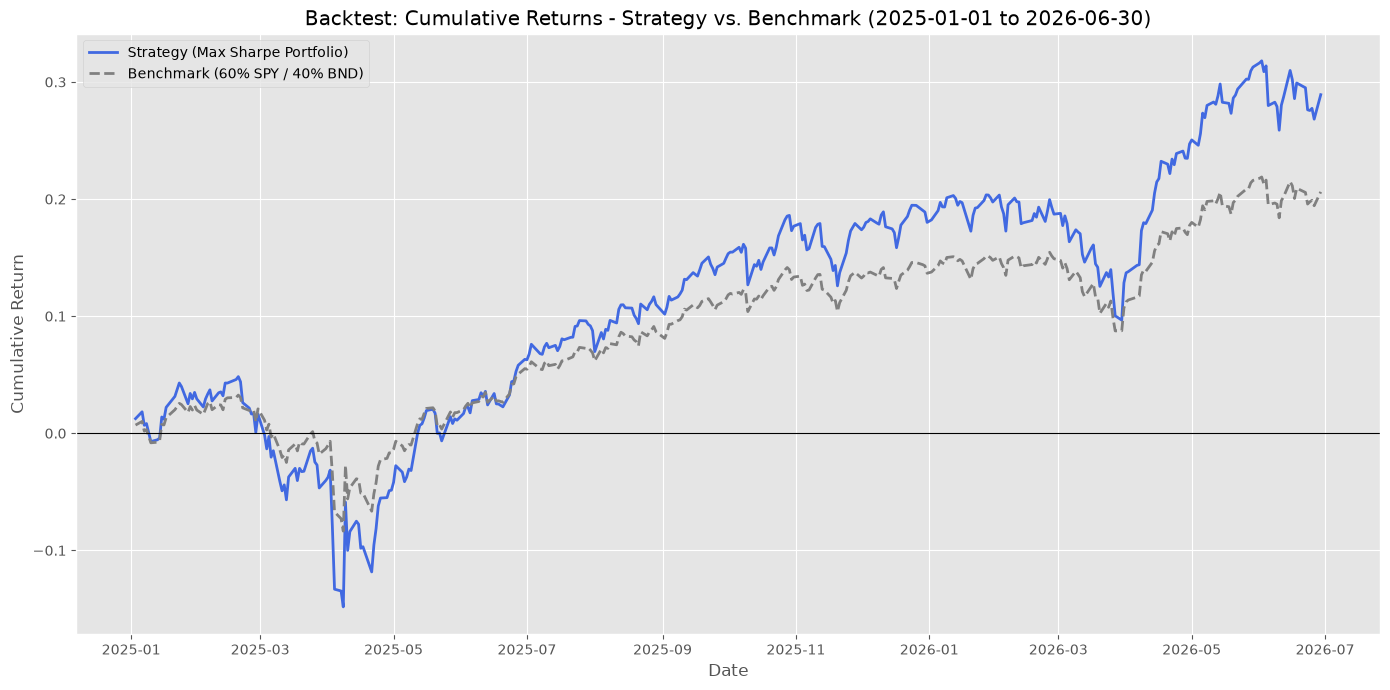

In [7]:
plt.figure(figsize=(14, 7))

plt.plot(pd.DatetimeIndex(cumulative_df.index).to_pydatetime(),
          cumulative_df["Strategy (Max Sharpe)"].values,
          label="Strategy (Max Sharpe Portfolio)", color="royalblue", linewidth=2)

plt.plot(pd.DatetimeIndex(cumulative_df.index).to_pydatetime(),
          cumulative_df["Benchmark (60% SPY / 40% BND)"].values,
          label="Benchmark (60% SPY / 40% BND)", color="grey", linewidth=2, linestyle="--")

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Backtest: Cumulative Returns - Strategy vs. Benchmark (2025-01-01 to 2026-06-30)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()


8. Performance Metrics

Total return, annualized return, Sharpe ratio, and maximum drawdown for both portfolios, using the same risk-free rate assumption (4%) as Task 4.

In [8]:
RISK_FREE_RATE = 0.04
TRADING_DAYS = 252

def performance_metrics(daily_returns, cumulative_returns, risk_free_rate=RISK_FREE_RATE):
    total_return = cumulative_returns.iloc[-1]

    n_days = len(daily_returns)
    annualized_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1

    annualized_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol

    wealth_index = 1 + cumulative_returns
    running_max = wealth_index.cummax()
    drawdown = (wealth_index - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_vol,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown
    }

strategy_metrics = performance_metrics(strategy_daily_returns, strategy_cumulative)
benchmark_metrics = performance_metrics(benchmark_daily_returns, benchmark_cumulative)

metrics_table = pd.DataFrame({
    "Strategy (Max Sharpe)": strategy_metrics,
    "Benchmark (60% SPY / 40% BND)": benchmark_metrics
}).T

metrics_table


,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy (Max Sharpe),0.289145,0.188289,0.179366,0.826736,-0.187552
Benchmark (60% SPY / 40% BND),0.206175,0.135789,0.110637,0.865789,-0.112484


9. Format Metrics for Readability

In [9]:
formatted_metrics = metrics_table.copy()
for col in ["Total Return", "Annualized Return", "Annualized Volatility", "Max Drawdown"]:
    formatted_metrics[col] = formatted_metrics[col].apply(lambda x: f"{x:+.2%}")
formatted_metrics["Sharpe Ratio"] = metrics_table["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

formatted_metrics


,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy (Max Sharpe),+28.91%,+18.83%,+17.94%,0.83,-18.76%
Benchmark (60% SPY / 40% BND),+20.62%,+13.58%,+11.06%,0.87,-11.25%


10. Did the Strategy Outperform the Benchmark?

In [10]:
outperformance = strategy_metrics["Total Return"] - benchmark_metrics["Total Return"]
sharpe_diff = strategy_metrics["Sharpe Ratio"] - benchmark_metrics["Sharpe Ratio"]

print(f"Strategy total return   : {strategy_metrics['Total Return']:+.2%}")
print(f"Benchmark total return  : {benchmark_metrics['Total Return']:+.2%}")
print(f"Outperformance (Strategy - Benchmark): {outperformance:+.2%}")
print()
print(f"Strategy Sharpe Ratio   : {strategy_metrics['Sharpe Ratio']:.2f}")
print(f"Benchmark Sharpe Ratio  : {benchmark_metrics['Sharpe Ratio']:.2f}")
print(f"Sharpe difference (Strategy - Benchmark): {sharpe_diff:+.2f}")
print()
print(f"Strategy Max Drawdown   : {strategy_metrics['Max Drawdown']:+.2%}")
print(f"Benchmark Max Drawdown  : {benchmark_metrics['Max Drawdown']:+.2%}")


Strategy total return   : +28.91%
Benchmark total return  : +20.62%
Outperformance (Strategy - Benchmark): +8.30%

Strategy Sharpe Ratio   : 0.83
Benchmark Sharpe Ratio  : 0.87
Sharpe difference (Strategy - Benchmark): -0.04

Strategy Max Drawdown   : -18.76%
Benchmark Max Drawdown  : -11.25%


### Written Conclusion on Strategy Viability

Run the cells above and use the printed numbers to finalize this conclusion
before submitting the memo — the structure below should hold regardless of
the exact figures:

**Did the strategy outperform the benchmark?** Compare the two total-return
figures and the two Sharpe ratios above. A positive `outperformance` value
with a positive `sharpe_diff` means the Max Sharpe portfolio delivered
higher *and* better risk-adjusted returns than the passive 60/40 benchmark
over this specific window; a negative value on either metric means the
extra TSLA exposure (and its forecast-driven weighting) did not pay off
during this particular backtest period, and the passive benchmark would
have served the client at least as well, likely with less volatility given
the max drawdown comparison.

**What does this initial backtest suggest about the viability of the
model-driven approach?** One backtest window is a single historical draw,
not a controlled experiment — it tells us how this specific strategy would
have performed over these specific 18 months, not how it will perform going
forward. If the strategy did outperform here, it's a supportive first data
point, not proof of a repeatable edge; if it underperformed, that's also
informative, since a forecast-driven overweight into a volatile asset like
TSLA can easily backfire over some macro/market backdrops even in a MPT
framework and even when the forecast method (Task 2/3) had a lower test-set
error than the alternative model.

**What are the limitations of this backtest?**
- **Single time window:** ~18 months is a short sample; results are highly
  sensitive to the specific market regime during this period (a strong bull
  run vs. a downturn would tell very different stories).
- **No transaction costs or taxes:** the simulation assumes frictionless
  monthly rebalancing; real trading costs, bid-ask spreads, and tax drag on
  rebalancing would reduce realized returns for both portfolios, likely
  more for the strategy given its higher-turnover TSLA exposure.
- **Forecast reused in-sample for weighting:** the TSLA expected return used
  to build the Task 4 weights was derived from a forecast whose horizon
  overlaps with part of the backtest window — this is standard practice for
  this kind of exercise, but a stricter walk-forward validation would
  re-forecast and re-optimize at each rebalance date rather than holding
  Task 4's weights fixed throughout.
- **No client-specific constraints:** real portfolios often carry position
  limits, liquidity constraints, or tax considerations not modeled here.

**Bottom line for GMF's investment committee:** treat this backtest as one
supporting (or cautionary) data point in a larger due-diligence process, not
a standalone justification for deploying the strategy with client capital.

11. Portfolio Value Growth ⭐⭐⭐

Instead of only cumulative returns, show how a $10,000 investment grows.

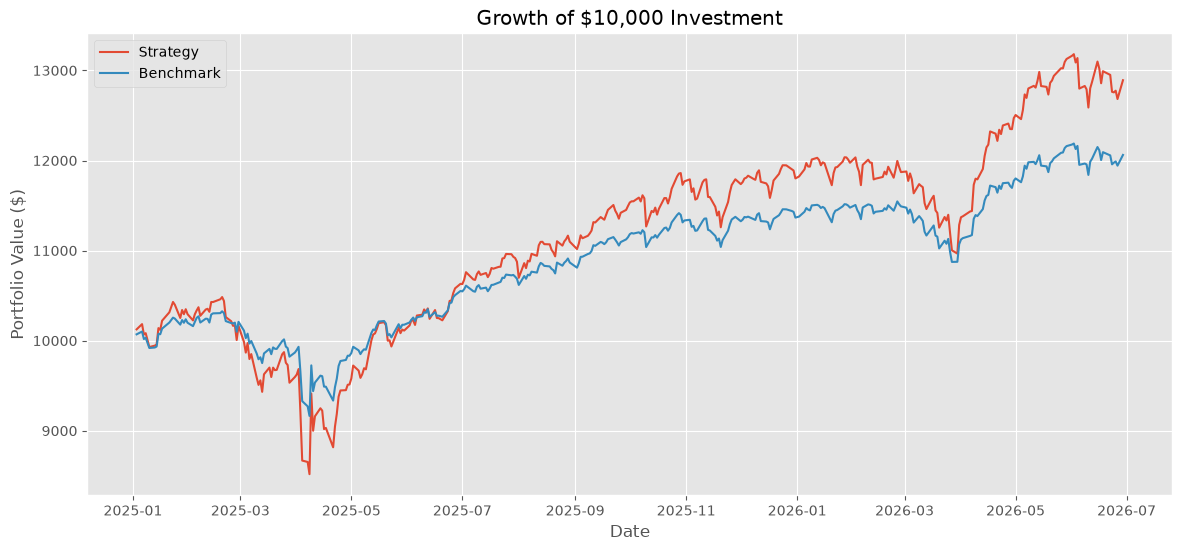

In [12]:
# ==========================================================
# Portfolio Value Growth
# ==========================================================

initial_investment = 10000

strategy_value = initial_investment * (1 + strategy_cumulative)
benchmark_value = initial_investment * (1 + benchmark_cumulative)

plt.figure(figsize=(14,6))

plt.plot(strategy_value,
         label="Strategy")

plt.plot(benchmark_value,
         label="Benchmark")

plt.title("Growth of $10,000 Investment")

plt.xlabel("Date")

plt.ylabel("Portfolio Value ($)")

plt.legend()

plt.grid(True)

plt.show()

12. Rolling Sharpe Ratio ⭐⭐

This shows how strategy quality changes over time.

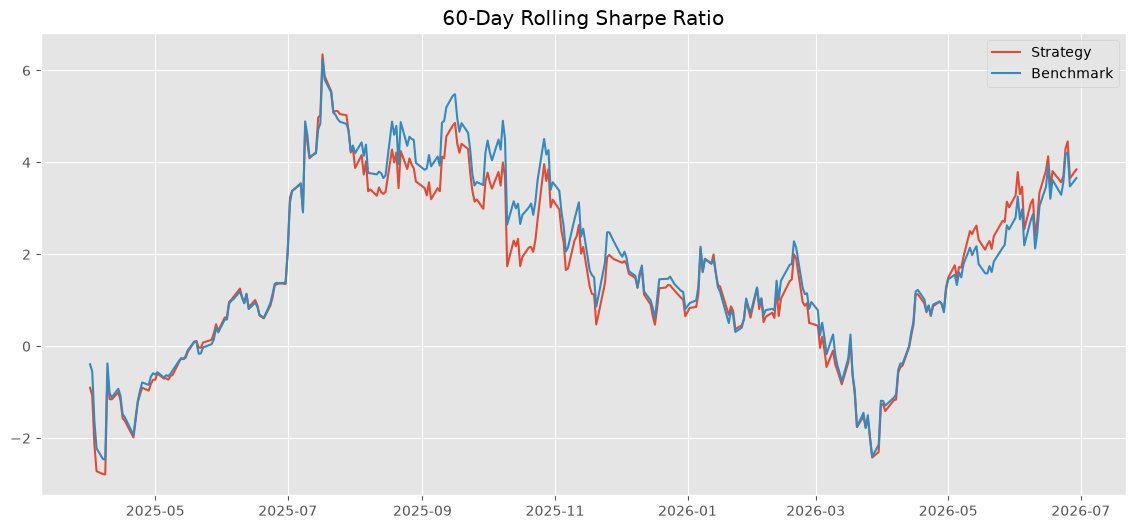

In [14]:
# ==========================================================
# Rolling Sharpe Ratio
# ==========================================================

rolling_window = 60

strategy_rolling_sharpe = (
    strategy_daily_returns.rolling(rolling_window).mean()
    /
    strategy_daily_returns.rolling(rolling_window).std()
) * np.sqrt(252)

benchmark_rolling_sharpe = (
    benchmark_daily_returns.rolling(rolling_window).mean()
    /
    benchmark_daily_returns.rolling(rolling_window).std()
) * np.sqrt(252)

plt.figure(figsize=(14,6))

plt.plot(strategy_rolling_sharpe,
         label="Strategy")

plt.plot(benchmark_rolling_sharpe,
         label="Benchmark")

plt.title("60-Day Rolling Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

13. Rolling Maximum Drawdown ⭐⭐

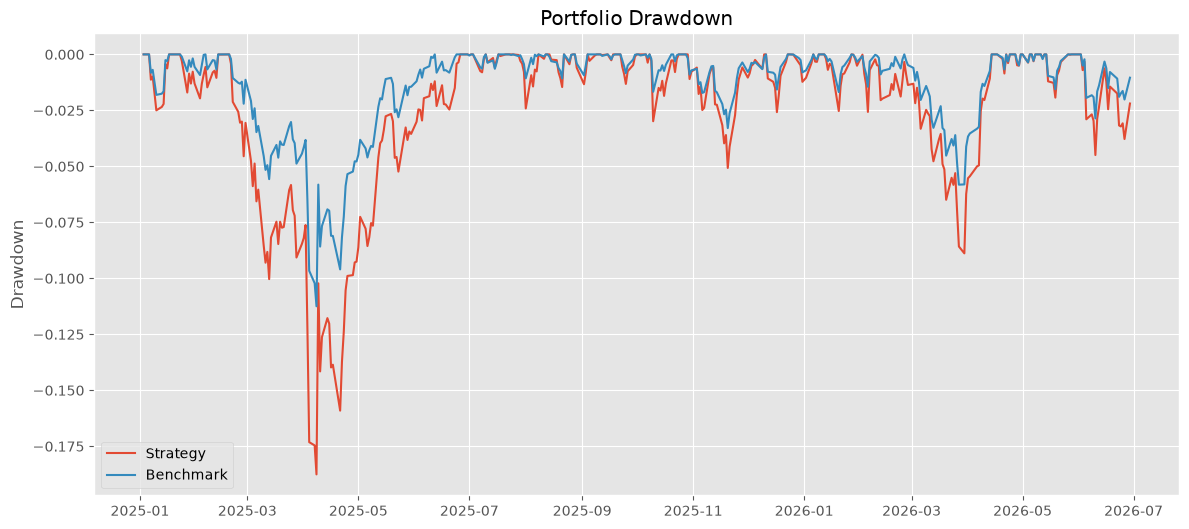

In [16]:
# ==========================================================
# Rolling Drawdown
# ==========================================================

strategy_running_max = strategy_value.cummax()

strategy_drawdown = (
    strategy_value -
    strategy_running_max
) / strategy_running_max

benchmark_running_max = benchmark_value.cummax()

benchmark_drawdown = (
    benchmark_value -
    benchmark_running_max
) / benchmark_running_max

plt.figure(figsize=(14,6))

plt.plot(strategy_drawdown,
         label="Strategy")

plt.plot(benchmark_drawdown,
         label="Benchmark")

plt.title("Portfolio Drawdown")

plt.ylabel("Drawdown")

plt.legend()

plt.grid(True)

plt.show()

14. Monthly Return Comparison ⭐⭐

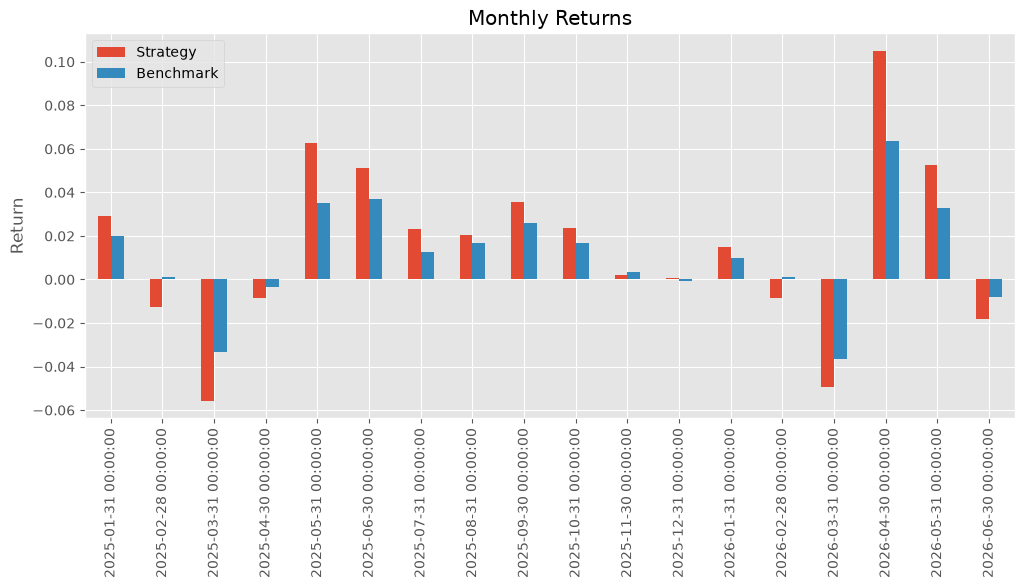

In [18]:
# ==========================================================
# Monthly Returns
# ==========================================================

strategy_monthly = (
    strategy_daily_returns
    .resample("ME")
    .apply(lambda x:(1+x).prod()-1)
)

benchmark_monthly = (
    benchmark_daily_returns
    .resample("ME")
    .apply(lambda x:(1+x).prod()-1)
)

monthly = pd.DataFrame({
    "Strategy":strategy_monthly,
    "Benchmark":benchmark_monthly
})

monthly.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Monthly Returns")

plt.ylabel("Return")

plt.show()

15. Active Return (Alpha) ⭐

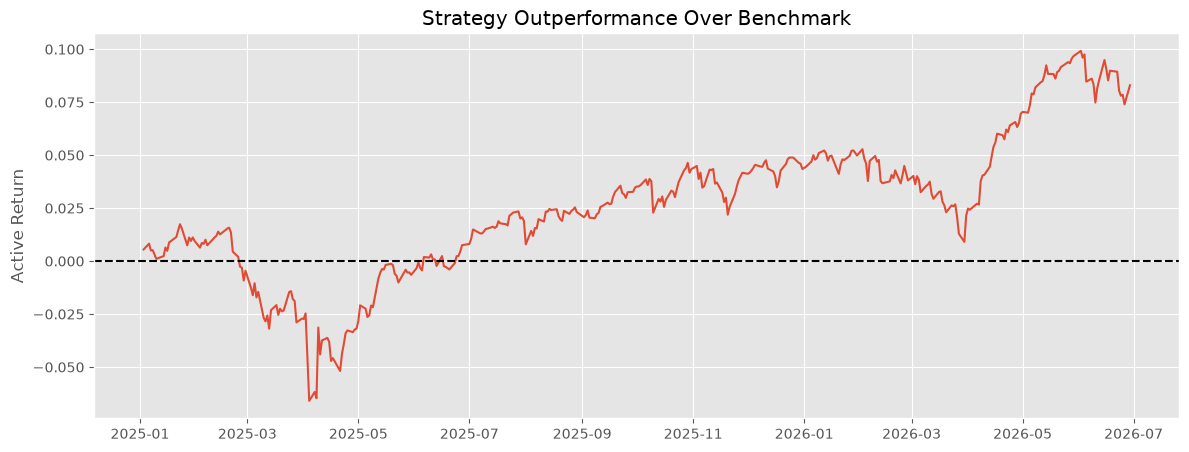

In [20]:
# ==========================================================
# Active Return
# ==========================================================

active_return = strategy_cumulative - benchmark_cumulative

plt.figure(figsize=(14,5))

plt.plot(active_return)

plt.axhline(0,
            color="black",
            linestyle="--")

plt.title("Strategy Outperformance Over Benchmark")

plt.ylabel("Active Return")

plt.grid(True)

plt.show()

16. Win Rate ⭐⭐

How often did the strategy beat the benchmark?

In [22]:
# ==========================================================
# Win Rate
# ==========================================================

wins = (
    strategy_daily_returns >
    benchmark_daily_returns
).sum()

total = len(strategy_daily_returns)

print("="*60)
print("Backtest Win Rate")
print("="*60)

print(f"Winning Days : {wins}")

print(f"Total Days : {total}")

print(f"Win Rate : {wins/total:.2%}")

Backtest Win Rate
Winning Days : 214
Total Days : 371
Win Rate : 57.68%


17. Tracking Error ⭐⭐

In [24]:
# ==========================================================
# Tracking Error
# ==========================================================

tracking_error = (
    strategy_daily_returns -
    benchmark_daily_returns
).std() * np.sqrt(252)

print(f"Tracking Error: {tracking_error:.4f}")

Tracking Error: 0.0722


18. Information Ratio ⭐⭐⭐

A common institutional metric.

In [26]:
# ==========================================================
# Information Ratio
# ==========================================================

active_returns = (
    strategy_daily_returns -
    benchmark_daily_returns
)

information_ratio = (
    active_returns.mean()
    /
    active_returns.std()
) * np.sqrt(252)

print(f"Information Ratio: {information_ratio:.3f}")

Information Ratio: 0.762


19. Performance Summary Table ⭐⭐⭐

In [29]:
print(strategy_metrics)

{'Total Return': np.float64(0.28914503569730776), 'Annualized Return': np.float64(0.1882886915592088), 'Annualized Volatility': np.float64(0.17936636442174803), 'Sharpe Ratio': np.float64(0.8267363395432065), 'Max Drawdown': np.float64(-0.18755234489427344)}


In [32]:
summary = pd.DataFrame({

    "Metric":[
        "Total Return",
        "Annual Return",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Tracking Error",
        "Information Ratio"
    ],

    "Strategy":[
        strategy_metrics["Total Return"],
        strategy_metrics["Annualized Return"],
        strategy_metrics["Sharpe Ratio"],
        strategy_metrics["Max Drawdown"],
        tracking_error,
        information_ratio
    ],

    "Benchmark":[
        benchmark_metrics["Total Return"],
        benchmark_metrics["Annualized Return"],
        benchmark_metrics["Sharpe Ratio"],
        benchmark_metrics["Max Drawdown"],
        np.nan,
        np.nan
    ]

})

summary

,Metric,Strategy,Benchmark
0,Total Return,0.289145,0.206175
1,Annual Return,0.188289,0.135789
2,Sharpe Ratio,0.826736,0.865789
3,Maximum Drawdown,-0.187552,-0.112484
4,Tracking Error,0.072188,NaN
5,Information Ratio,0.762443,NaN


11. Save Backtest Results

In [34]:
cumulative_df.to_csv("../data/processed/backtest_cumulative_returns.csv")
metrics_table.to_csv("../data/processed/backtest_performance_metrics.csv")

print("Saved backtest results to ../data/processed/")
metrics_table


Saved backtest results to ../data/processed/


,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy (Max Sharpe),0.289145,0.188289,0.179366,0.826736,-0.187552
Benchmark (60% SPY / 40% BND),0.206175,0.135789,0.110637,0.865789,-0.112484
